In [1]:
import pandas as pd
from risk_experiment.cogmodels.fit_model import build_model, get_data
import os.path as op
import pymc as pm
import arviz as az

from tqdm.contrib.itertools import product
import seaborn as sns

In [2]:
def get_info(model_label):

    session = None
    bids_folder = '/data/ds-risk'
    roi = 'npcr'

    data = get_data(model_label, session, bids_folder, roi)
    model = build_model(model_label, data, roi)
    idata = az.from_netcdf(op.join(bids_folder, 'derivatives', 'cogmodels', f'model-{model_label}_trace.netcdf'))

    with model.estimation_model:
        pm.compute_log_likelihood(idata)

    return idata


In [3]:
get_info('neural32')

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:01<00:00, 19.71it/s]


Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
	> constant_data

In [4]:
idata = {}
for model_label in ['neural32', 'neural36', 'neural37']:
    idata[model_label] = get_info(model_label)

100%|██████████| 30/30 [00:01<00:00, 16.54it/s]


100%|██████████| 30/30 [00:01<00:00, 20.31it/s]


100%|██████████| 30/30 [00:01<00:00, 19.99it/s]


In [5]:
import arviz as az

In [6]:
az.compare(idata)

/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/stats/stats.py:805: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/stats/stats.py:805: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
neural37,0,-5895.217865,209.911561,0.000000,0.682744,53.271032,0.000000,False,log
neural36,1,-5896.477989,202.905805,1.260123,0.317256,53.272341,2.651706,True,log
neural32,2,-5913.087099,252.823186,17.869233,0.000000,53.099326,4.805478,True,log


In [18]:
import matplotlib.pyplot as plt

n1_evidence_sd_mu    0.0435
dtype: float64
n1_evidence_sd_mu    0.051667
dtype: float64
n1_evidence_sd_mu    0.009833
dtype: float64


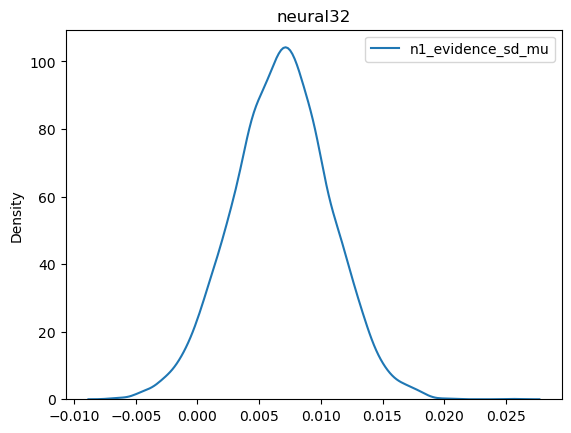

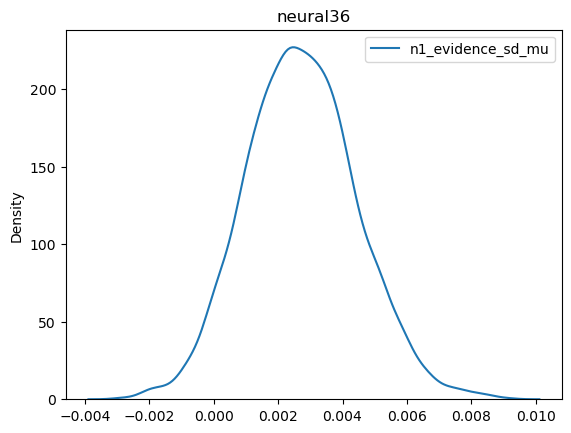

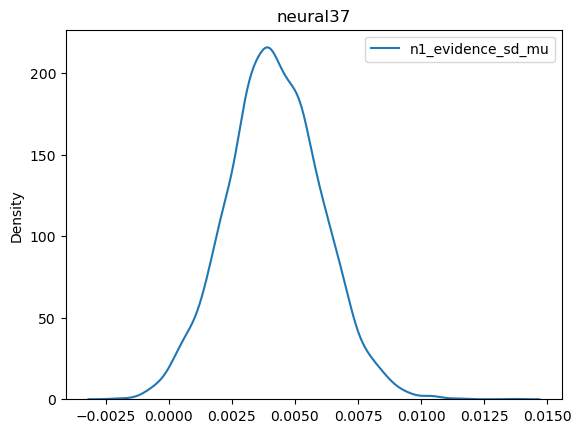

In [20]:
for key, id in idata.items():
    plt.figure()
    tmp = id.posterior['n1_evidence_sd_mu'].to_dataframe().xs('sd', level='n1_evidence_sd_regressors')

    print((tmp < 0.0).mean())

    plt.title(key)
    sns.kdeplot(tmp)